In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. Cài đặt thư viện

In [2]:
# Cài đặt các thư viện cần thiết cho Speech-to-Text và PhoBERT
!pip install SpeechRecognition pydub pyvi datasets transformers[torch] accelerate -U
!apt-get install ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
Reading package lists... Done
Bui

Xử lý dữ liệu và chia tập (80% Train, 20% Val)

In [7]:
import speech_recognition as sr
import os
import pandas as pd
from pyvi import ViTokenizer
from datasets import Dataset
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

r = sr.Recognizer()
model_name = "wonrax/phobert-base-vietnamese-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Hàm đọc dữ liệu từ cấu trúc thư mục 3 nhãn
def process_segmented_folders_to_df(root_path):
    all_data = []
    label_map = {'Tichcuc': 0, 'Tieucuc': 1, 'Trungtinh': 2}

    print(f"--- Đang xử lý: {root_path} ---")
    for emotion_folder, label in label_map.items():
        folder_path = os.path.join(root_path, emotion_folder)
        if not os.path.exists(folder_path): continue
        for filename in os.listdir(folder_path):
            if filename.lower().endswith(('.wav', '.flac')):
                try:
                    with sr.AudioFile(os.path.join(folder_path, filename)) as source:
                        audio_data = r.record(source)
                        text = r.recognize_google(audio_data, language='vi-VN')
                        all_data.append({"text": ViTokenizer.tokenize(text), "labels": label})
                except: continue
    return pd.DataFrame(all_data)

# Đọc và chia dữ liệu
train_path = '/content/drive/MyDrive/DATN_CHI_TRAM/model_voice/model_voice_train_by_vid/voice_of_vid'
df_full = process_segmented_folders_to_df(train_path)

# Chuyển sang Dataset và chia 80/20
full_ds = Dataset.from_pandas(df_full)
dataset_dict = full_ds.train_test_split(test_size=0.2, seed=42)

def tokenize_fn(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = dataset_dict["train"].map(tokenize_fn, batched=True)
tokenized_val = dataset_dict["test"].map(tokenize_fn, batched=True)

--- Đang xử lý: /content/drive/MyDrive/DATN_CHI_TRAM/model_voice/model_voice_train_by_vid/voice_of_vid ---


Map:   0%|          | 0/167 [00:00<?, ? examples/s]

Map:   0%|          | 0/42 [00:00<?, ? examples/s]

In [8]:
print(f"Số lượng mẫu huấn luyện: {len(tokenized_train)}")
print(f"Số lượng mẫu validation: {len(tokenized_val)}")

if len(tokenized_train) == 0:
    raise ValueError("Tập dữ liệu huấn luyện đang bị rỗng, hãy kiểm tra lại đường dẫn hoặc hàm đọc file!")

Số lượng mẫu huấn luyện: 167
Số lượng mẫu validation: 42


Huấn luyện lại (Fine-tuning) PhoBERT

In [9]:
# Cập nhật tham số TrainingArguments
training_args = TrainingArguments(
    output_dir="./datn_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=5,
    load_best_model_at_end=True,
    remove_unused_columns=False  # <--- THÊM DÒNG NÀY VÀO
)

# Sau đó khởi tạo lại Trainer và chạy train
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,0.667974
2,No log,0.338942
3,No log,0.235640
4,No log,0.271624
5,No log,0.282089


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=105, training_loss=0.5633702232724145, metrics={'train_runtime': 212.7291, 'train_samples_per_second': 3.925, 'train_steps_per_second': 0.494, 'total_flos': 54924925950720.0, 'train_loss': 0.5633702232724145, 'epoch': 5.0})

In [10]:
save_path = "/content/drive/MyDrive/DATN_CHI_TRAM/model_speech_to_text/saved_model_text_new"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"Đã lưu model mới thành công tại: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Đã lưu model mới thành công tại: /content/drive/MyDrive/DATN_CHI_TRAM/model_speech_to_text/saved_model_text_new


4. Đánh giá và lưu kết quả

In [11]:
from sklearn.metrics import classification_report
import torch

def evaluate(model, tokenizer, val_ds):
    model.eval()
    y_true = val_ds["labels"]
    y_pred = []

    for text in val_ds["text"]:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(model.device)
        with torch.no_grad():
            pred = torch.argmax(model(**inputs).logits, dim=-1).item()
        y_pred.append(pred)

    print(classification_report(y_true, y_pred, target_names=["Tích cực", "Tiêu cực", "Trung tính"]))

evaluate(model, tokenizer, dataset_dict["test"])

              precision    recall  f1-score   support

    Tích cực       0.92      0.85      0.88        13
    Tiêu cực       1.00      1.00      1.00        13
  Trung tính       0.88      0.94      0.91        16

    accuracy                           0.93        42
   macro avg       0.93      0.93      0.93        42
weighted avg       0.93      0.93      0.93        42



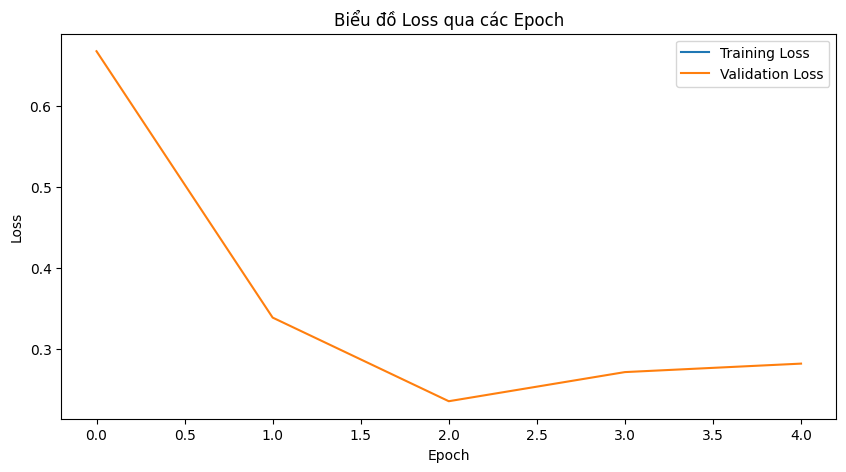

In [12]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_loss = [x['loss'] for x in log_history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(eval_loss, label='Validation Loss')
plt.title('Biểu đồ Loss qua các Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

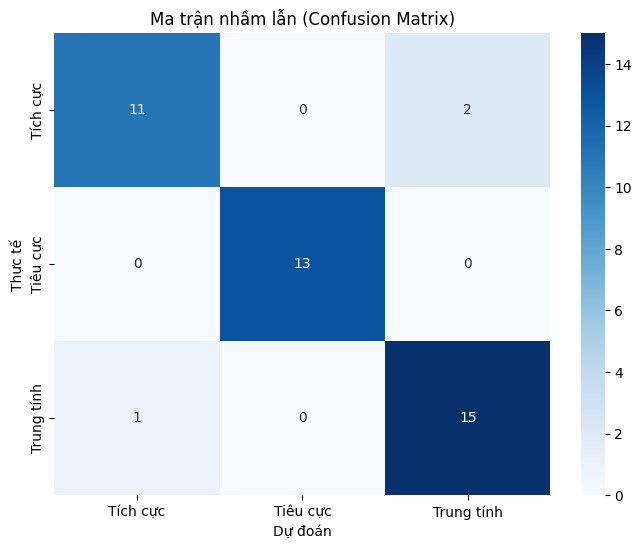

In [15]:
# 1. Chạy đánh giá và lưu kết quả vào biến global
def evaluate(model, tokenizer, val_ds):
    model.eval()
    y_true = val_ds["labels"]
    y_pred = []
    for text in val_ds["text"]:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(model.device)
        with torch.no_grad():
            pred = torch.argmax(model(**inputs).logits, dim=-1).item()
        y_pred.append(pred)
    return y_true, y_pred # Trả kết quả về

# Lưu kết quả vào biến toàn cục y_true, y_pred
y_true, y_pred = evaluate(model, tokenizer, dataset_dict["test"])

# 2. Vẽ Confusion Matrix ngay sau khi đã có y_true, y_pred
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
labels = ["Tích cực", "Tiêu cực", "Trung tính"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

In [16]:
# Kiểm tra đối chiếu nhãn và văn bản sau khi tách từ (tương tự như trong file của bạn)
samples = df_full.sample(n=10) # Lấy 10 mẫu ngẫu nhiên từ df_full
reverse_map = {0: "Tích cực", 1: "Tiêu cực", 2: "Trung tính"}

print(f"{'NHÃN GỐC':<15} | {'VĂN BẢN ĐÃ TÁCH TỪ':<40}")
print("-" * 60)
for index, row in samples.iterrows():
    print(f"{reverse_map[row['labels']]:<15} | {row['text'].replace('_', ' '):<40}")

NHÃN GỐC        | VĂN BẢN ĐÃ TÁCH TỪ                      
------------------------------------------------------------
Tích cực        | Bạn có cách giải thích rất dễ hiểu lôi cuốn mình học được rất nhiều điều sau khi mà đọc những cái bài chia sẻ ngắn gọn của bạn
Trung tính      | chúng ta nên xây dựng thói quen tiết kiệm tiền bạc từ khi còn trẻ để có một khoản dự phòng vững chắc cho những kế hoạch lớn trong tương lai
Tiêu cực        | Tôi cảm thấy vô cùng hối hận bởi vì đã không dành nhiều thời gian cho người thân khi mà họ còn ở bên cạnh mình giờ muốn ở bên cạnh họ cũng khó có thể được như trước nữa
Trung tính      | Tôi thấy việc học thêm những kỹ năng mới là điều cần thiết trong thời đại này nó giúp mở ra nhiều cơ hội nghề nghiệp hơn
Tích cực        | bạn đã có một bước chân dài trong công việc rồi đấy Hãy Duy trì phong độ này và không ngừng cập nhật kiến thức mới nhé
Trung tính      | Bạn có biết cách sửa lỗi định dạng trong bài văn bản này không tôi đã cố gắng thử rất nhiều cách